In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gurobipy import *
import gurobipy as gp
from gurobipy import GRB
sns.set(style ="whitegrid", font_scale=1.5)
from matplotlib.ticker import MultipleLocator
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
custom_colors = ["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
color_palette = np.array(["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"])
color = ['#93003a', '#00429d', '#93c4d2', '#6ebf7c']
matplotlib.rcParams.update({'legend.fontsize': 14, 'legend.handlelength': 2})
from tqdm import tqdm
import sys
import os
import pickle
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import importlib
import re
from geopy.distance import geodesic

### Prepare input

#### Load `uam_system_model` dependencies

In [2]:
from uam_system_model.StarNetworkJFK import StarNetwork
from uam_system_model.utils.visualize import plot_parameters, plot_travel_time

In [3]:
vertiports = ["UIU", "CHI"]

flight_distance_matrix = np.array([[0, 129],
                                   [129, 0]])  # in miles
flight_time_matrix = np.array([[0, 70],
                               [70, 0]])  # in minutes
energy_consumption_matrix = np.array([[0, 0.5],
                                      [0.5, 0]])  # in kWh

import importlib
import uam_system_model.StarNetworkJFK
importlib.reload(uam_system_model.StarNetworkJFK)
from uam_system_model.StarNetworkJFK import StarNetwork

network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=flight_distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)


In [4]:
df = pd.read_csv("data/c_uiuc.csv")
df['hour'] = pd.to_datetime(df['trip_start_time']).dt.hour
c_uiuc = df.groupby('hour').size().reset_index(name='total_trips')
c_uiuc['od'] = 'UIU_CHI'
df = pd.read_csv("data/uiuc_c.csv")
df['hour'] = pd.to_datetime(df['trip_start_time']).dt.hour
uiuc_c = df.groupby('hour').size().reset_index(name='total_trips')
uiuc_c['od'] = 'CHI_UIU'
df = pd.concat([c_uiuc, uiuc_c], ignore_index=True)

df['total_trips'] *= 365

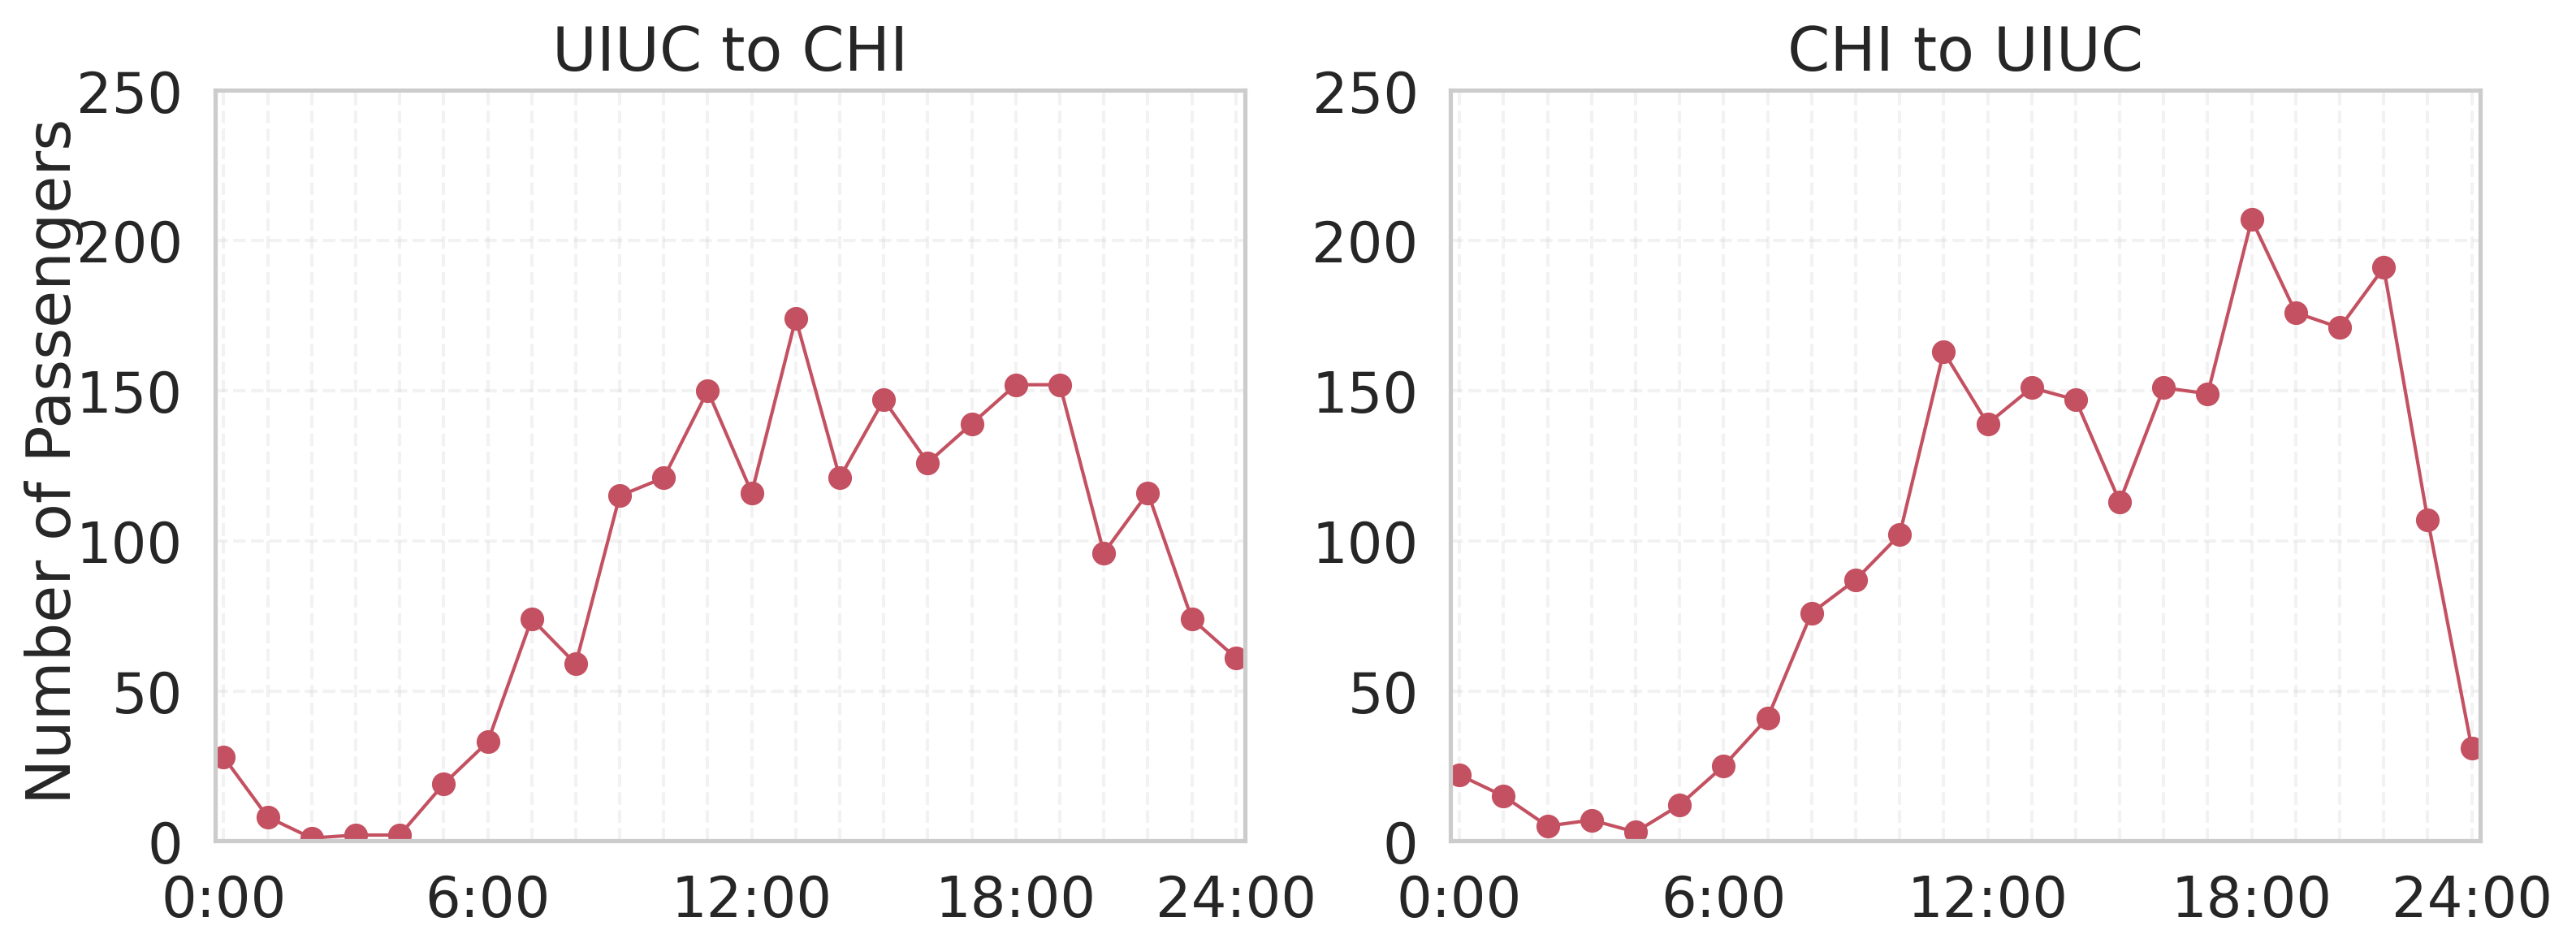

In [5]:
network.load_demand(df)
fig, ax = network.plot_pax(ylim=(0, 250));
ax[0].set_title("UIUC to CHI")
ax[1].set_title("CHI to UIUC")
ax[1].get_legend().remove()


In [6]:
uber_travel_time = np.zeros(shape=(len(vertiports), len(vertiports), 24))
uber_fare = np.zeros(shape=(len(vertiports), len(vertiports), 24))
first_or_last_distance = np.zeros(shape=(len(vertiports), len(vertiports), 24))

first_mile = np.zeros(shape=(len(vertiports), 24)) 
last_mile = np.zeros(shape=(len(vertiports), 24))

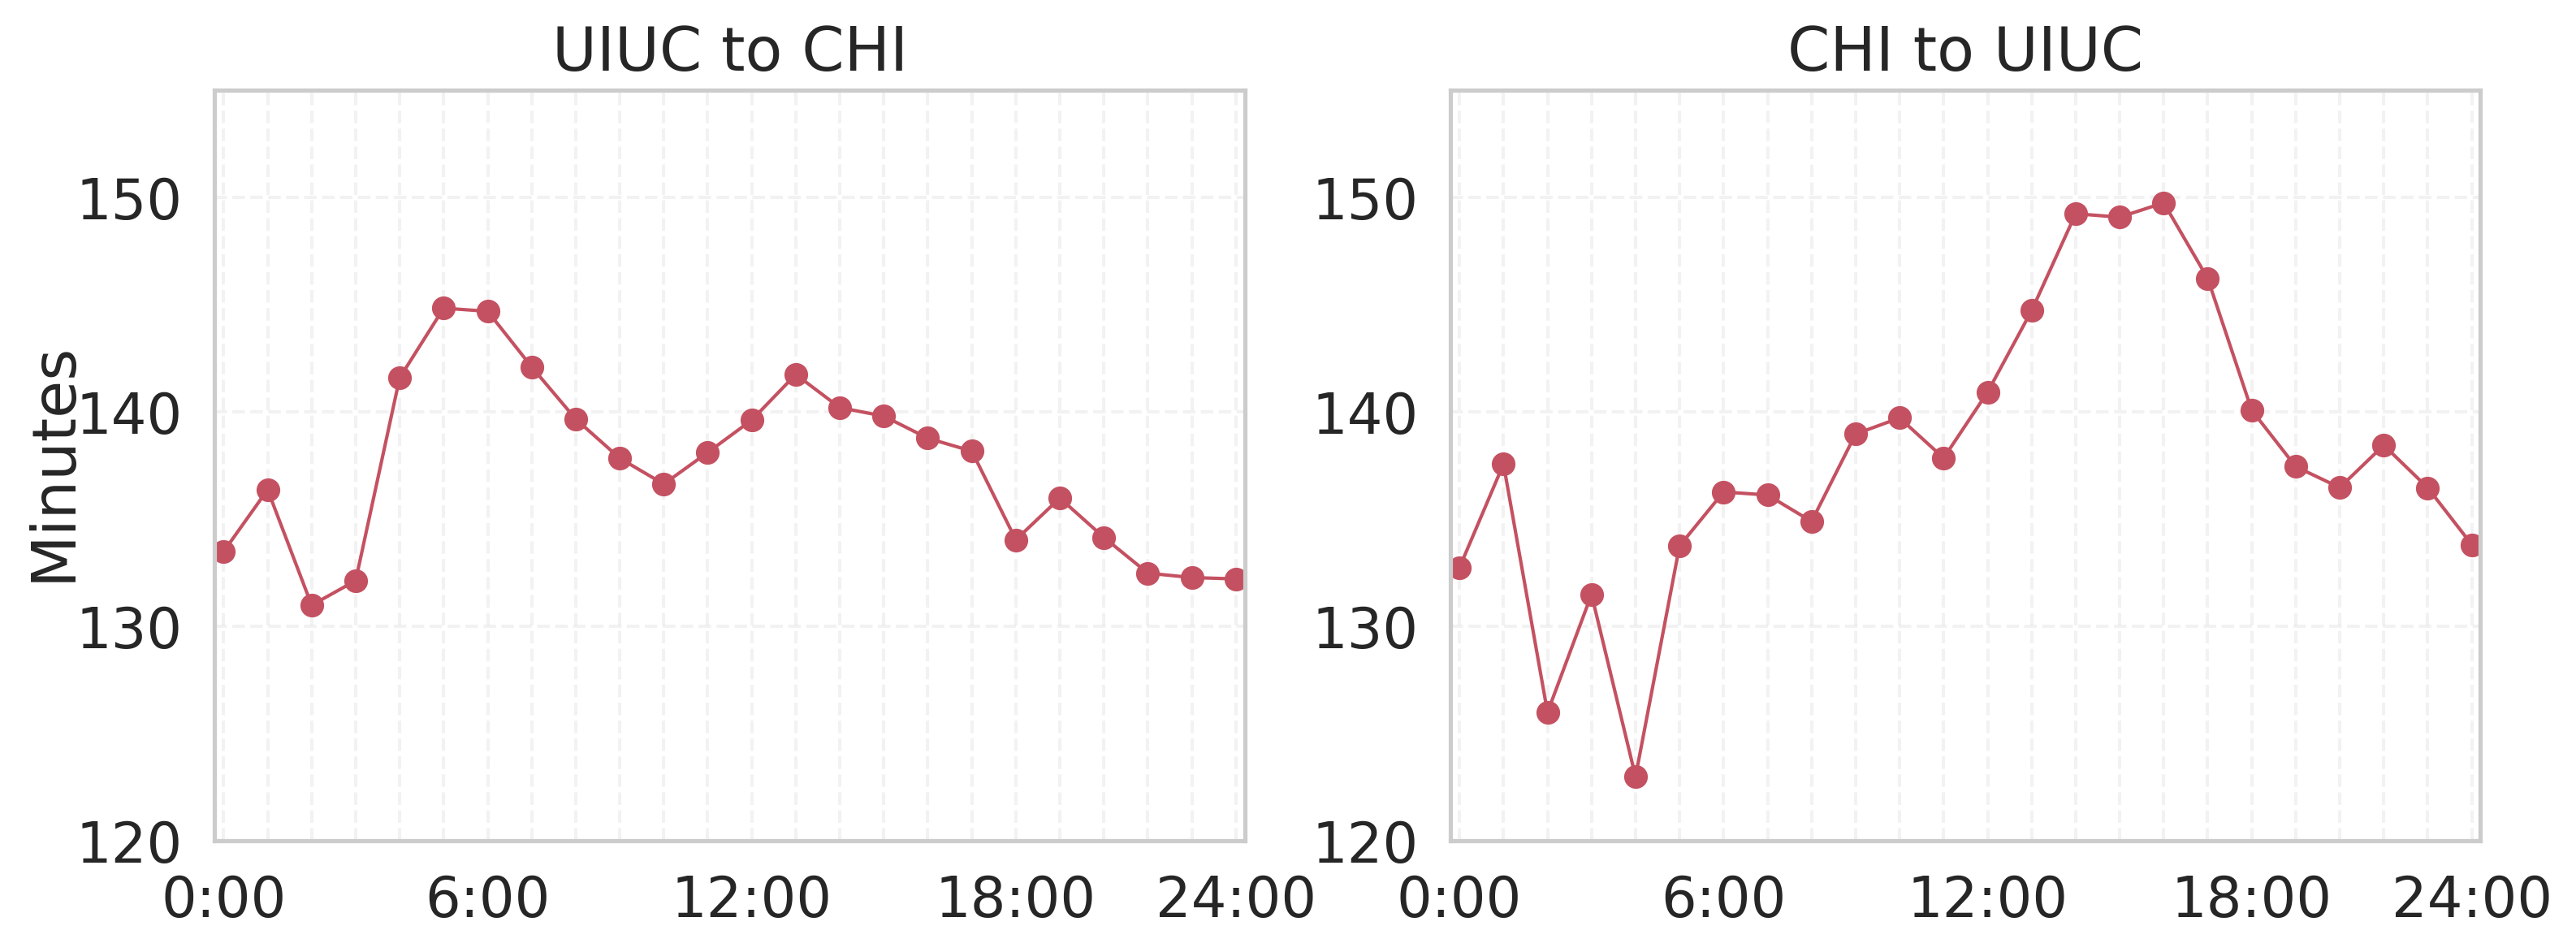

In [9]:
fig, ax = plot_travel_time(uber_travel_time, vertiports, ylabel="Minutes", ylim=(120, 155));
ax[0].set_title("UIUC to CHI")
ax[1].set_title("CHI to UIUC")
ax[1].get_legend().remove()

In [8]:
df = pd.read_csv("data/uiuc_c.csv")
df['hour'] = pd.to_datetime(df['trip_start_time']).dt.hour
c_uiuc = df.groupby('hour').size().reset_index(name='total_trips')

df_grouped = df.groupby("hour").agg({"hour": "size", "Driving_IVTT_min": "mean", "FM_duration_min": "mean", "LM_duration_min": "mean", "Driving_Fare_USD": "mean", "FM_fare_USD": "mean", "LM_fare_USD": "mean"})
df_grouped = df_grouped.rename(columns={"hour": "total_trips"})
df_grouped = df_grouped.reset_index()


for _, row in df_grouped.iterrows():
    hour = int(row['hour'])
    uber_travel_time[0, 1, hour] = row['Driving_IVTT_min']
    first_mile[0, hour] = row['FM_duration_min']
    last_mile[1, hour] = row['LM_duration_min']
    uber_fare[0, 1, hour] = row['Driving_Fare_USD']

df = pd.read_csv("data/c_uiuc.csv")
df['hour'] = pd.to_datetime(df['trip_start_time']).dt.hour
c_uiuc = df.groupby('hour').size().reset_index(name='total_trips')

df_grouped = df.groupby("hour").agg({"hour": "size", "Driving_IVTT_min": "mean", "FM_duration_min": "mean", "LM_duration_min": "mean", "Driving_Fare_USD": "mean", "FM_fare_USD": "mean", "LM_fare_USD": "mean"})
df_grouped = df_grouped.rename(columns={"hour": "total_trips"})
df_grouped = df_grouped.reset_index()

for _, row in df_grouped.iterrows():
    hour = int(row['hour'])
    uber_travel_time[1, 0, hour] = row['Driving_IVTT_min']
    first_mile[1, hour] = row['FM_duration_min']
    last_mile[0, hour] = row['LM_duration_min']
    uber_fare[1, 0, hour] = row['Driving_Fare_USD']

first_or_last_distance = np.array([[0, 4], [8, 0]])  # in miles
first_or_last_distance = np.repeat(first_or_last_distance[:, :, np.newaxis], 24, axis=2)


In [50]:

from uam_system_model.Pricing import PricingOptimizer
from tqdm import tqdm

In [27]:
op = PricingOptimizer(StarNetwork=network)

fs = np.arange(10, 65, 5)
casm = np.arange(0.6, 0.9, 0.1)

for f in tqdm(fs):
    for c in casm:
        df = op.optimize(
            time_resolution=30,
            num_vehicles=f,
            uber_travel_time=uber_travel_time,
            uber_fare=uber_fare,
            first_mile_time=first_mile,
        last_mile_time=last_mile,
        first_or_last_distance=first_or_last_distance,
        uam_flight_time = flight_time_matrix,
        uam_distance_matrix=flight_distance_matrix,
        optimality_gap=0.05,
        value_of_time=32.63,
        time_limit=1800,
        utility_type="betas",
        CASM=c,
        verbose=False
    )

        df.to_csv(f"results/{f}_{round(c*10, 0)}.csv", index=False)

  0%|          | 0/11 [00:00<?, ?it/s]

Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800


  9%|▉         | 1/11 [00:01<00:13,  1.33s/it]

Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800


 18%|█▊        | 2/11 [00:02<00:13,  1.50s/it]

...

 82%|████████▏ | 9/11 [01:53<00:38, 19.26s/it]

Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800


 91%|█████████ | 10/11 [02:36<00:26, 26.72s/it]

Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800


100%|██████████| 11/11 [03:20<00:00, 18.19s/it]


In [183]:
folder = "results2/"


files = os.listdir(folder)
fleetsize = []
casm = []
total_rev = []
cost = []
w_rasm = []
market_share = []
num_flights = []
num_pax = []
for file in files:
    fleetsize.append(int(file.split("_")[0]))
    casm.append(int(file.split("_")[1].split(".")[0])/10)
    
    df = pd.read_csv(folder + file)
    total_rev.append(df['total_revenue'].sum())
    cost.append((df['num_flights'] * df['distance'] * casm[-1] * 4).sum())
    w_rasm.append((df['rev_per_mile'] * df['uam_pax']).sum() / df['uam_pax'].sum())
    market_share.append(df['uam_pax'].sum() / network.pax_arrival_times.shape[0] * 100)
    num_flights.append(df['num_flights'].sum())
    num_pax.append(df['uam_pax'].sum())
    


results = pd.DataFrame({
    'fleet_size': fleetsize,
    'CASM': casm,
    'total_revenue': total_rev,
    'profit': np.array(total_rev) - np.array(cost),
    'rasm': w_rasm,
    'market_share': market_share,
    'num_flights': num_flights,
    'num_pax': num_pax,
    'load_factor': np.array(num_pax) / np.array(num_flights) / 4 * 100
}).sort_values(by=['fleet_size', 'CASM']).reset_index(drop=True)
results


,fleet_size,CASM,total_revenue,profit,rasm,market_share,num_flights,num_pax,load_factor
0,10,0.6,13691.694832,1926.894832,0.701038,3.458990,38.000000,151.400000,99.605263
1,10,0.7,13716.468507,-9.131493,0.702307,3.458990,38.000000,151.400000,99.605263
2,10,0.8,7486.404528,-769.595472,0.725427,1.827736,20.000000,80.000000,100.000000
3,10,0.9,3649.220037,-994.779963,0.707213,0.913868,10.000000,40.000000,100.000000
4,15,0.6,21246.192537,2670.192537,0.690852,5.446653,60.000000,238.400000,99.333333
5,15,0.7,18964.936904,182.536904,0.706803,4.752113,52.000000,208.000000,100.000000
6,15,0.8,11219.201409,-1164.798591,0.724755,2.741604,30.000000,120.000000,100.000000
7,15,0.9,5465.081860,-1500.918140,0.706083,1.370802,15.000000,60.000000,100.000000
8,20,0.6,26839.178283,3619.178283,0.696304,6.826594,75.000000,298.800000,99.600000
9,20,0.7,24820.680363,259.080363,0.708948,6.200594,68.000000,271.400000,99.779412


[Text(0.5, 0, 'Fleet Size'), Text(0, 0.5, 'Profit ($)')]

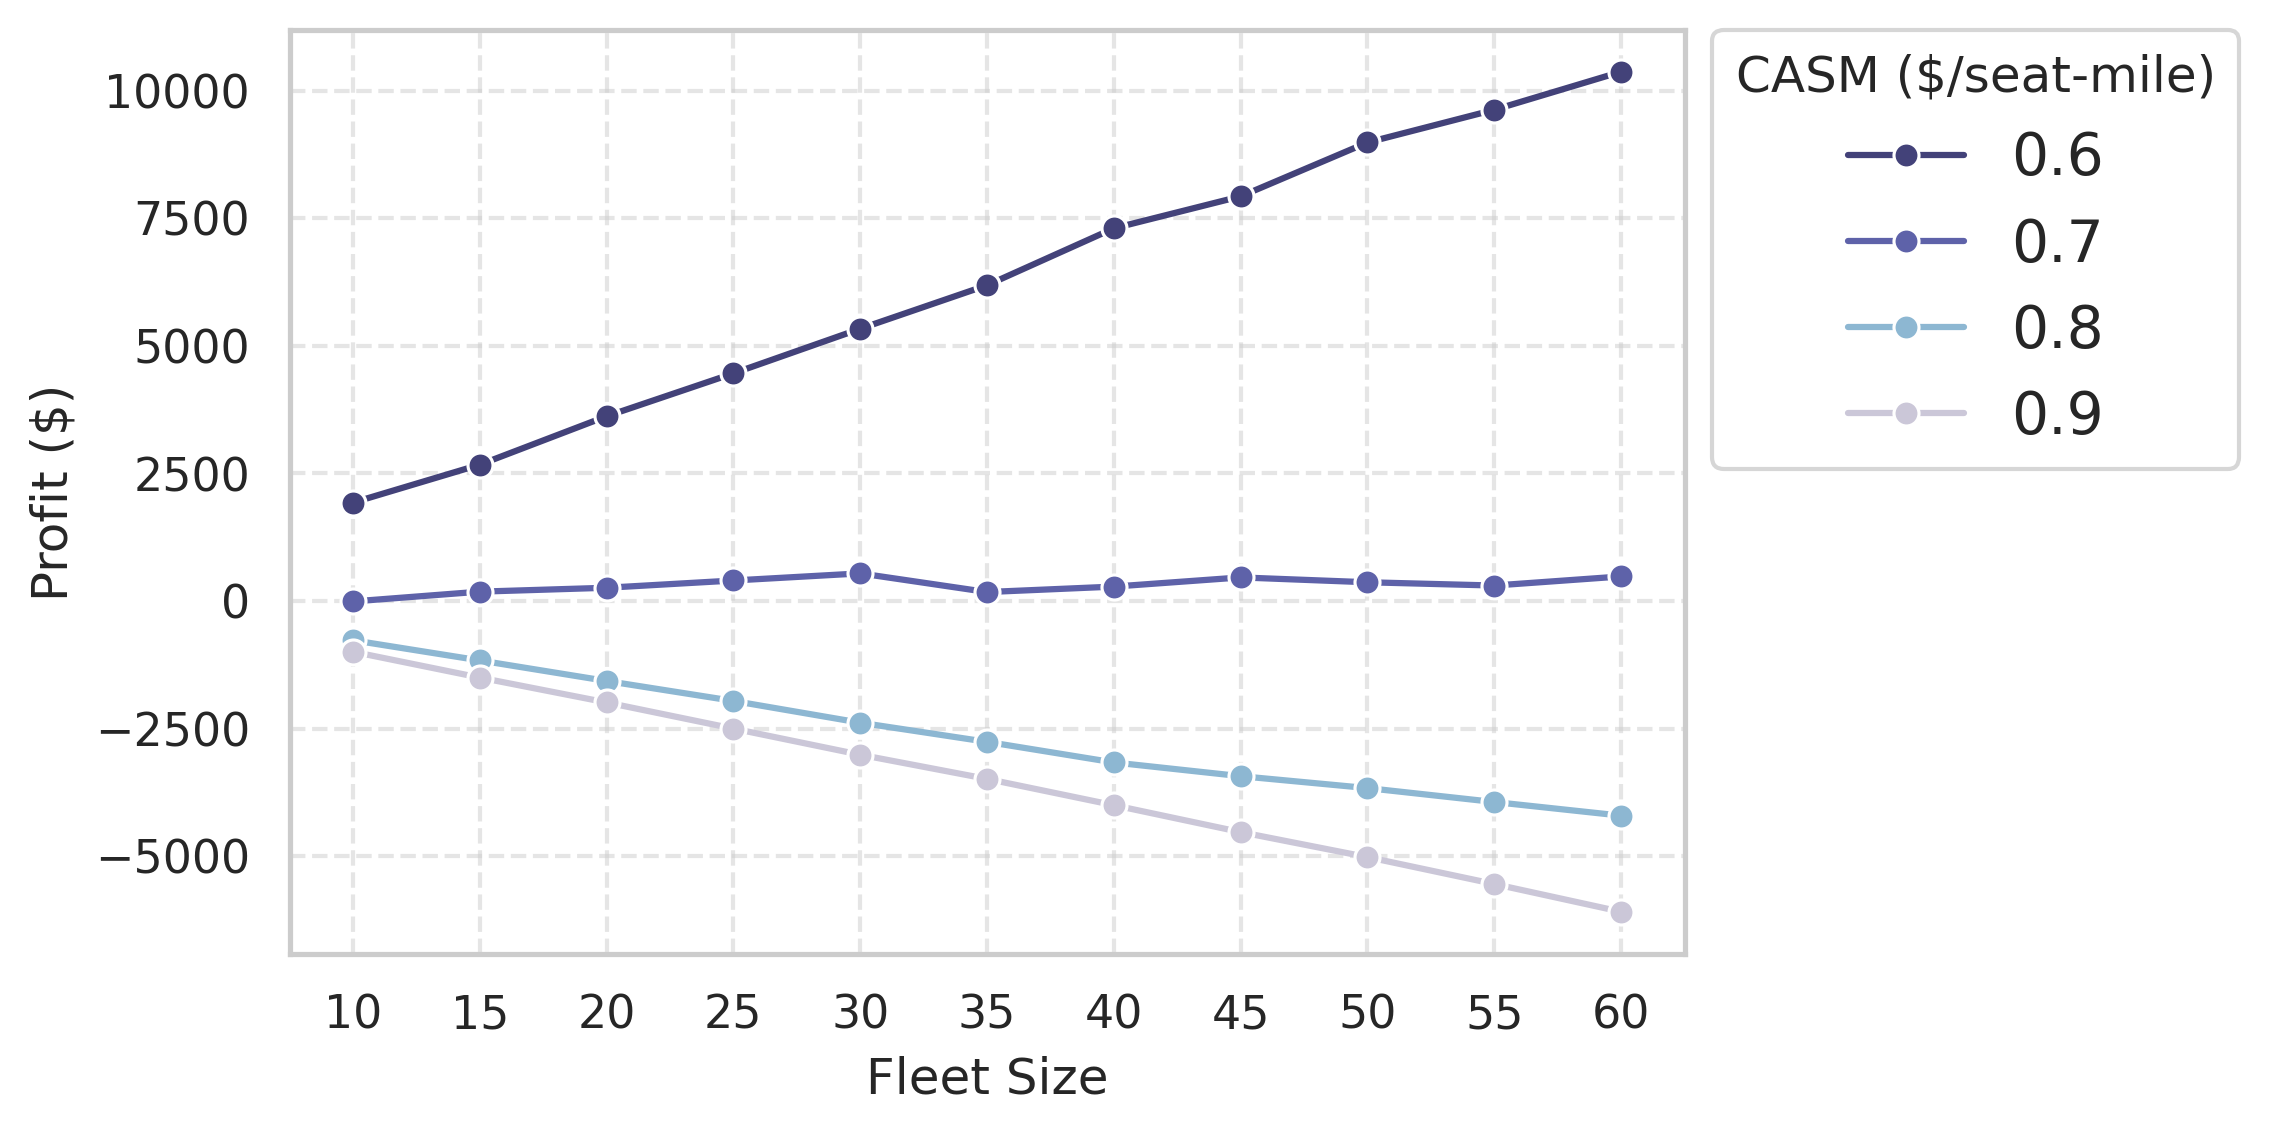

In [184]:

fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
sns.lineplot(data=results, x='fleet_size', y='profit', hue='CASM', marker='o', palette=custom_colors[::-1], ax=ax)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0, title="CASM ($/seat-mile)")
ax.set(xlabel="Fleet Size", ylabel="Profit ($)")

[Text(0.5, 0, 'Fleet Size'), Text(0, 0.5, 'Load Factor (%)'), (95.0, 100.0)]

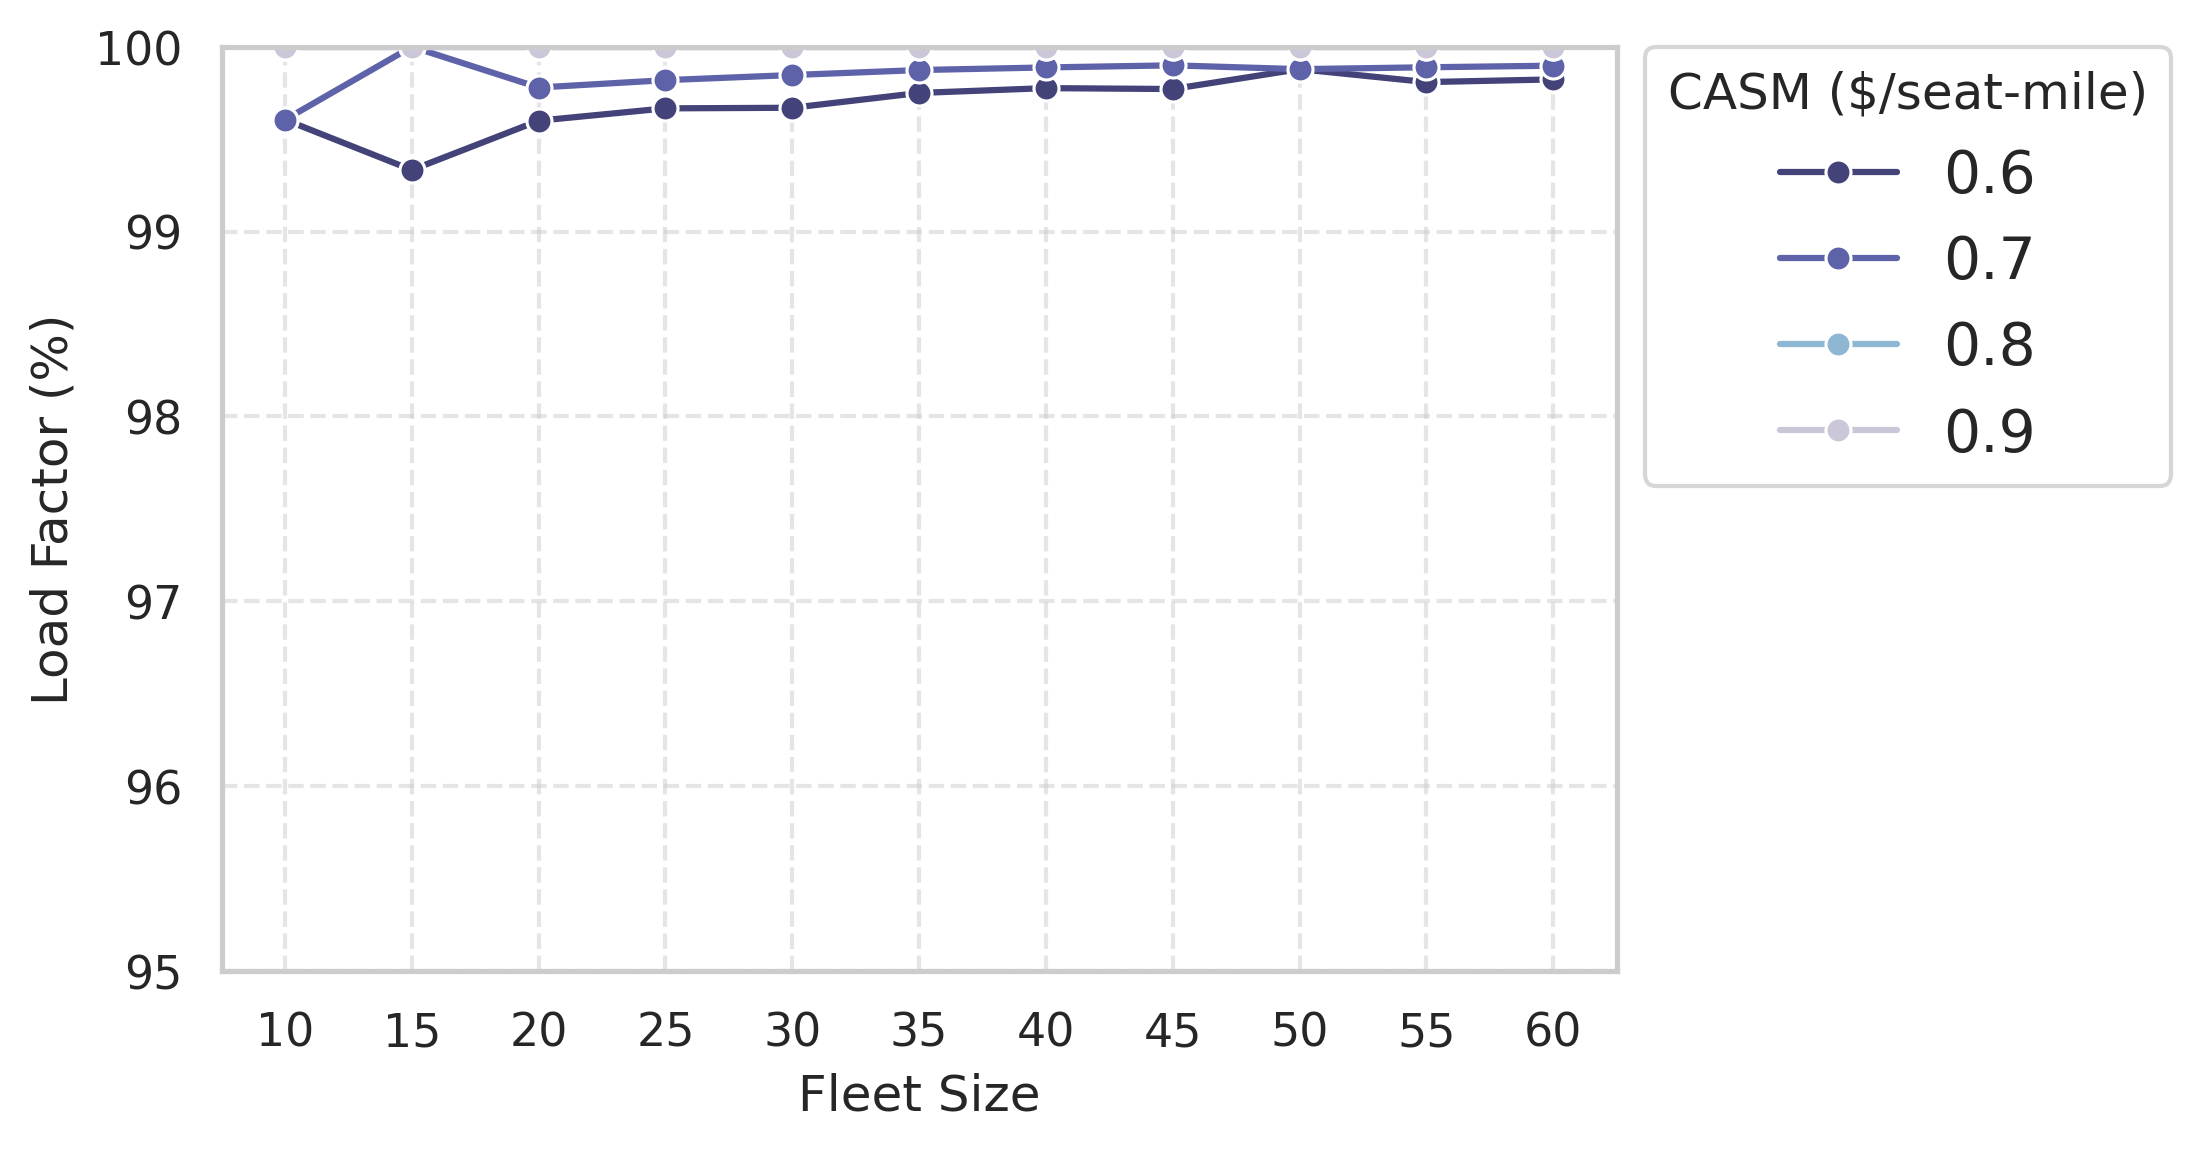

In [185]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
sns.lineplot(data=results, x='fleet_size', y='load_factor', hue='CASM', marker='o', palette=custom_colors[::-1], ax=ax)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0, title="CASM ($/seat-mile)")
ax.set(xlabel="Fleet Size", ylabel="Load Factor (%)", ylim=(95, 100))

[Text(0.5, 0, 'Fleet Size'), Text(0, 0.5, 'RASM')]

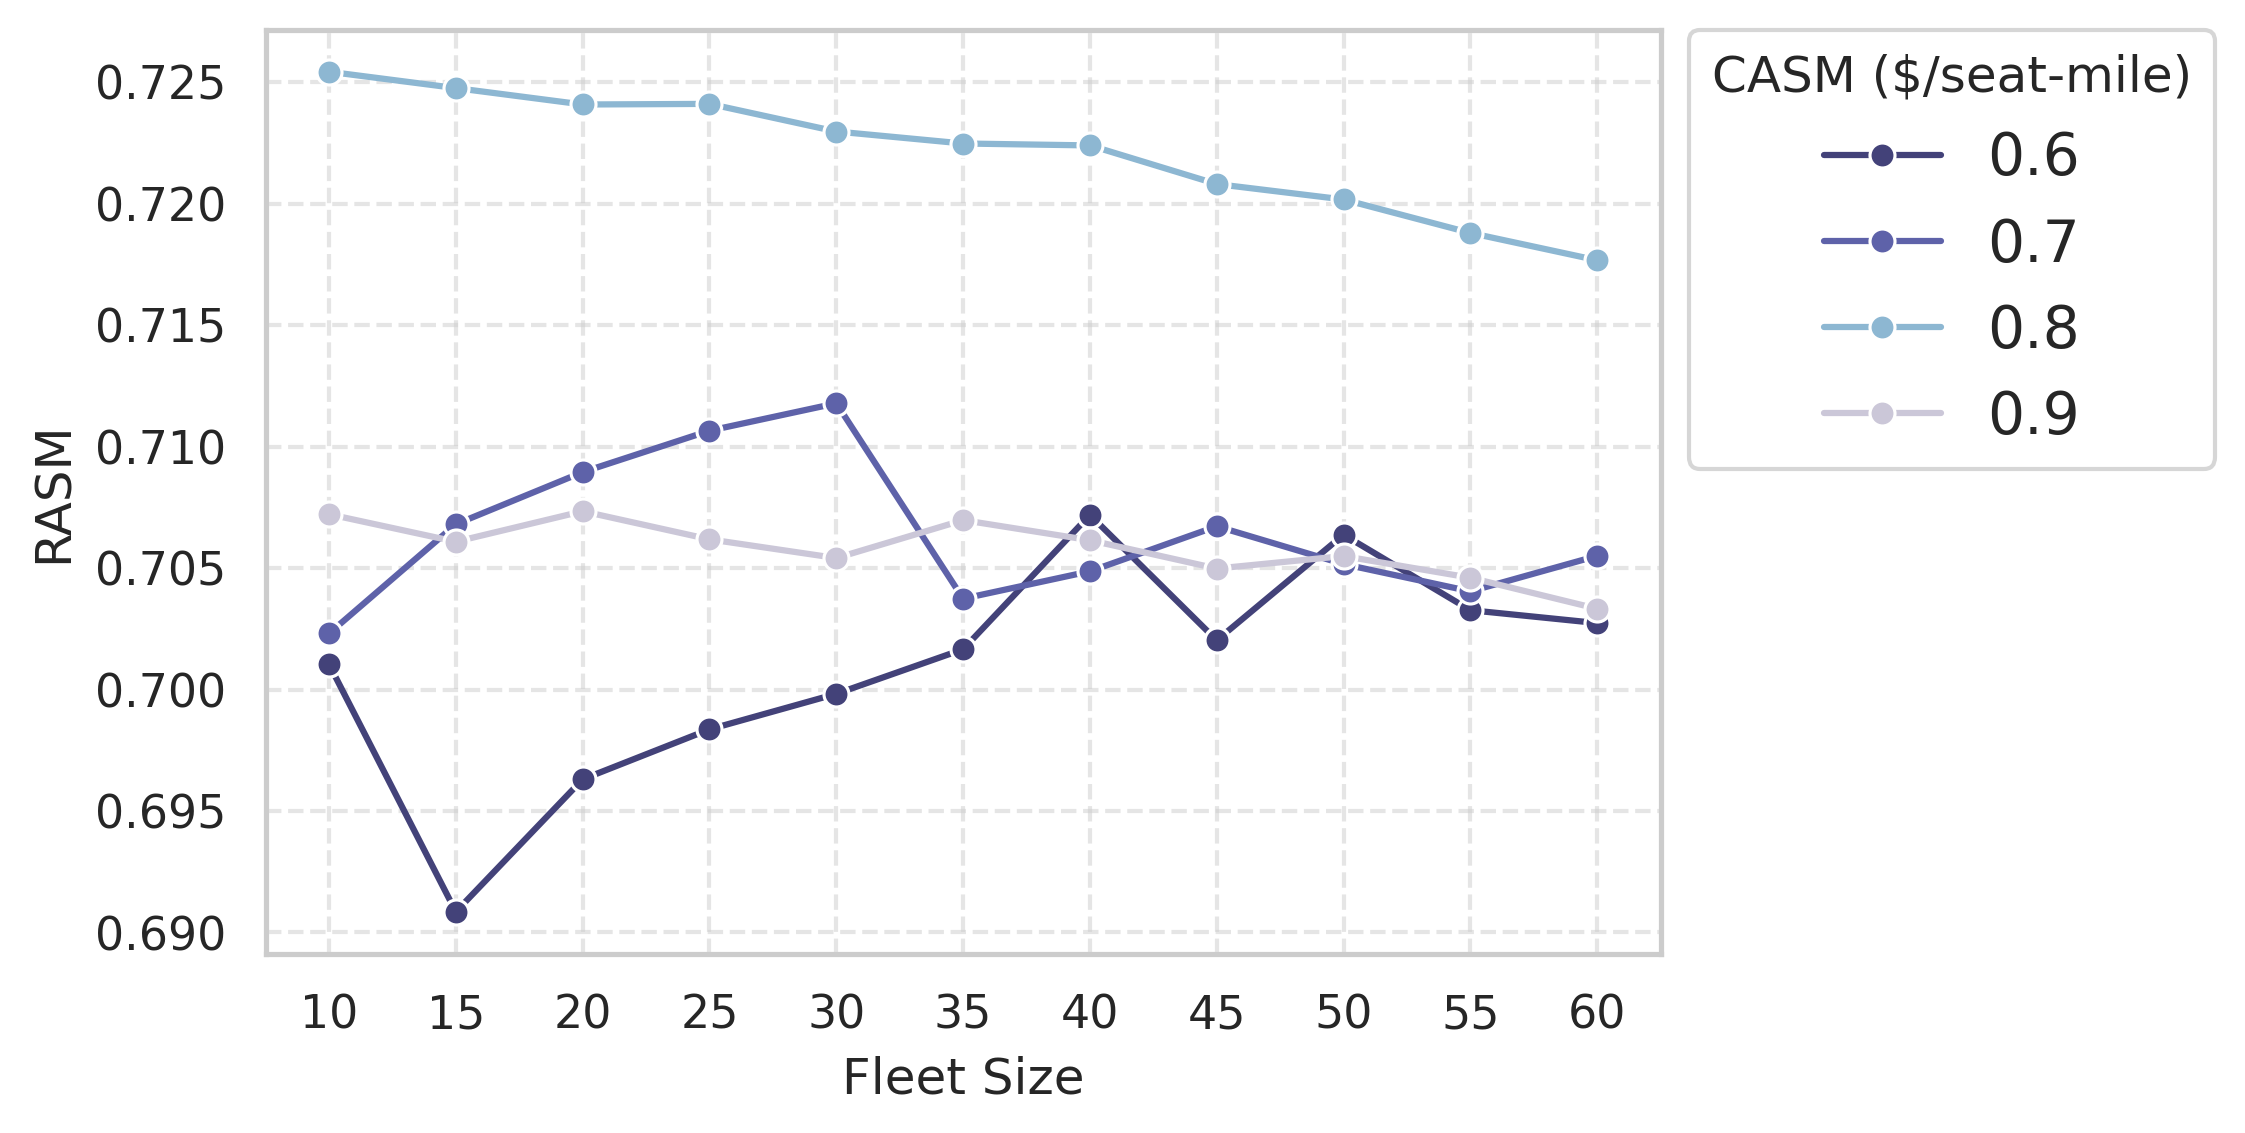

In [186]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
sns.lineplot(data=results, x='fleet_size', y='rasm', hue='CASM', marker='o', palette=custom_colors[::-1], ax=ax)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0, title="CASM ($/seat-mile)")
ax.set(xlabel="Fleet Size", ylabel="RASM")

[Text(0.5, 0, 'Fleet Size'), Text(0, 0.5, 'Market Share (%)'), (0.0, 20.0)]

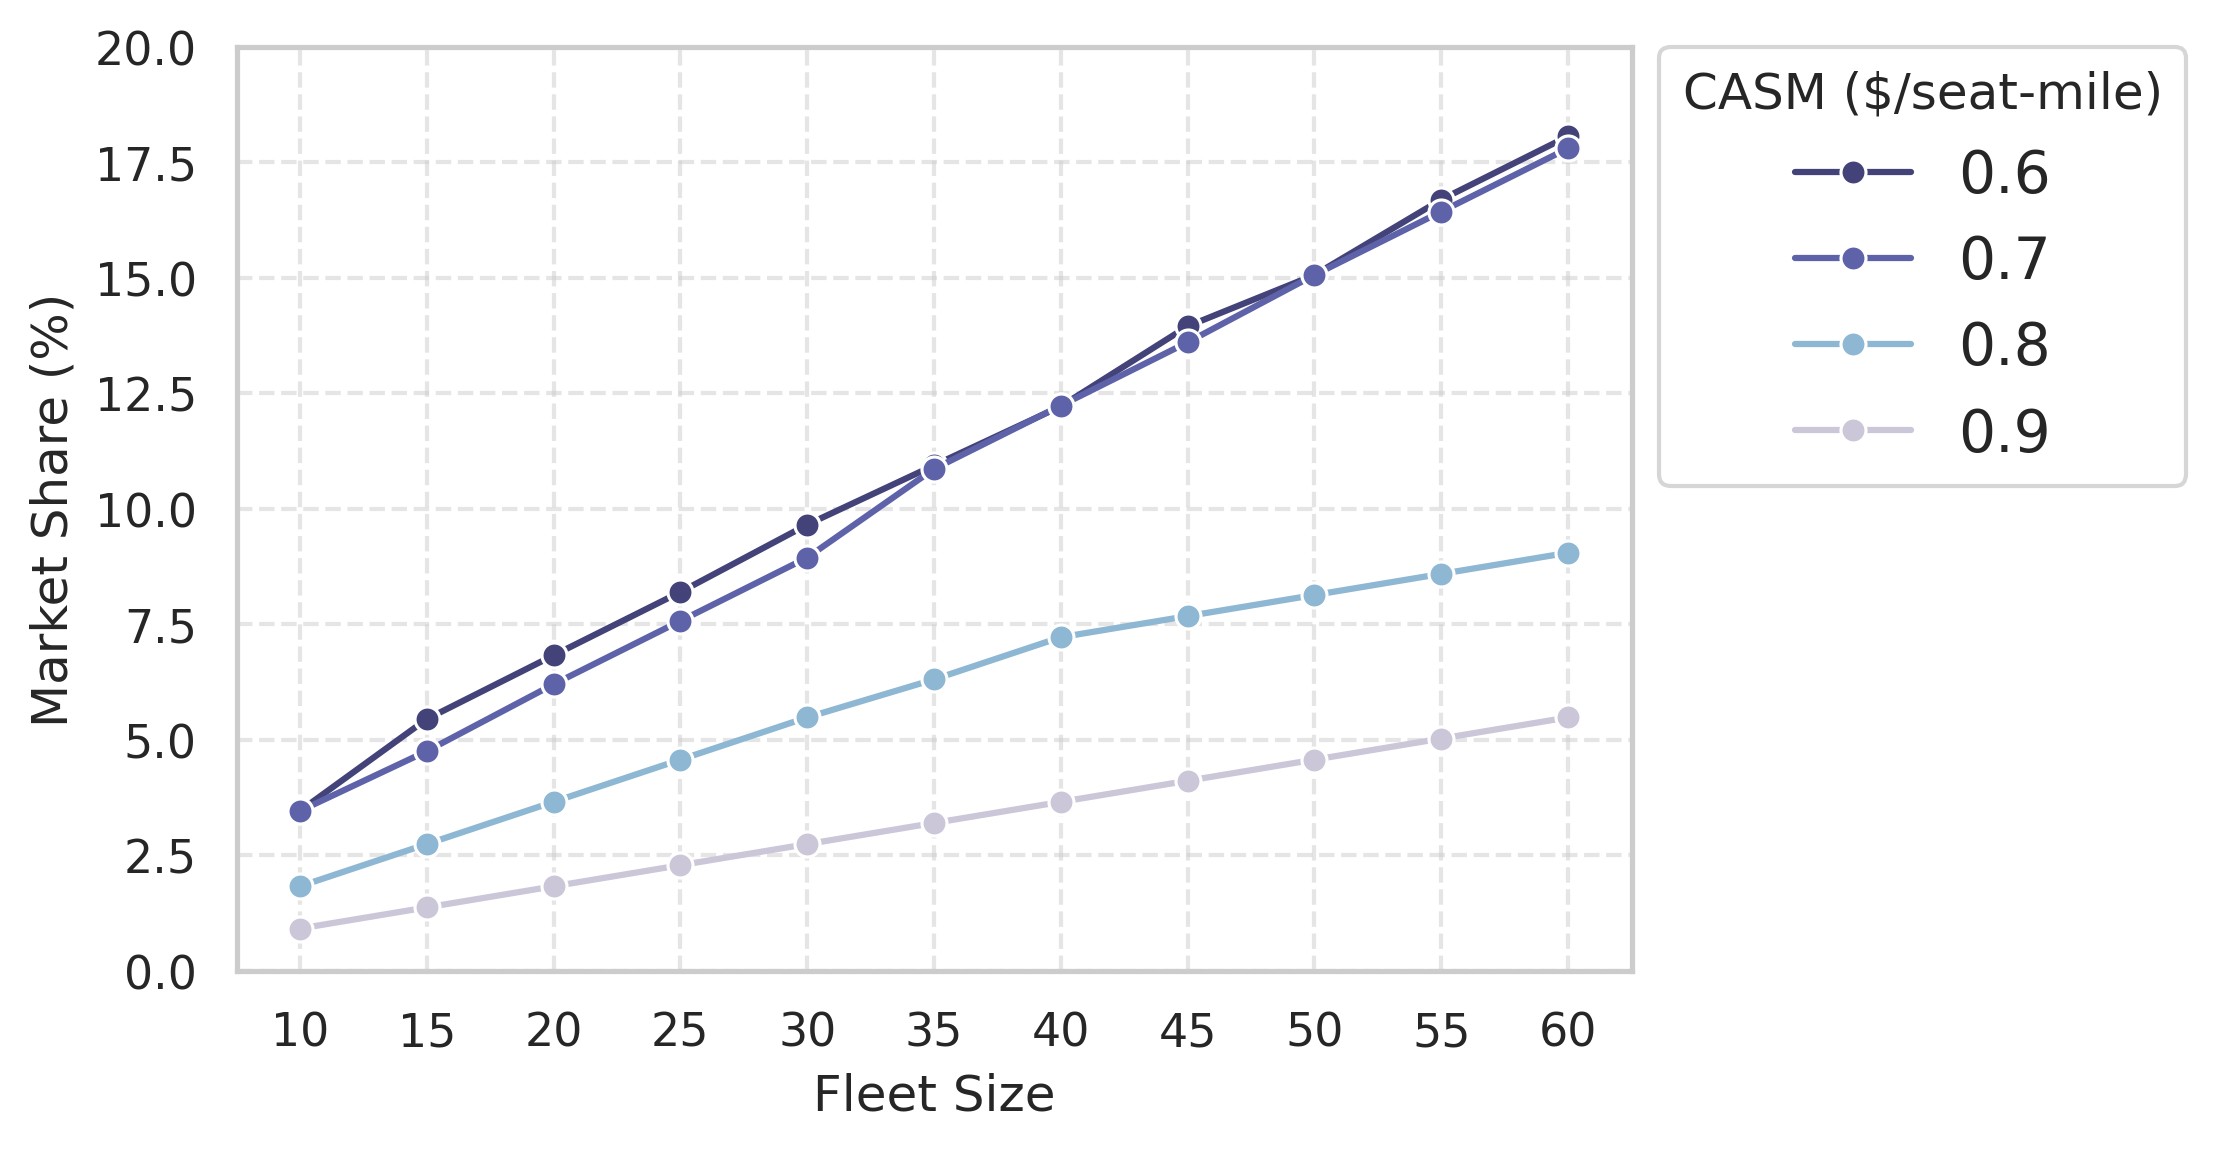

In [187]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
sns.lineplot(data=results, x='fleet_size', y='market_share', hue='CASM', marker='o', palette=custom_colors[::-1], ax=ax)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0, title="CASM ($/seat-mile)")
ax.set(xlabel="Fleet Size", ylabel="Market Share (%)", ylim=(0, 20))



In [35]:
import uam_system_model.utils.PricingOpSummary
importlib.reload(uam_system_model.utils.PricingOpSummary)
from uam_system_model.utils.PricingOpSummary import PricingOpSummary

In [55]:
df

,flight_index,percentage_uam,num_flights,fare,origin_vertiport_id,destination_vertiport_id,passenger_arrival_time_slot,num_pax,distance,uam_pax,rev_per_mile,markets,total_revenue
0,0,0.650000,2.0,70.132153,0,1,0,1,129,0.65,0.543660,CHI,45.585900
1,1,0.650000,5.0,73.738645,0,1,1,12,129,7.80,0.571617,CHI,575.161430
2,2,0.650000,4.0,66.759329,1,0,1,10,129,6.50,0.517514,CHI,433.935635
3,3,0.650000,6.0,74.010562,0,1,2,15,129,9.75,0.573725,CHI,721.602976
4,4,0.650000,4.0,66.759329,1,0,2,12,129,7.80,0.517514,CHI,520.722762
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,90,0.266667,3.0,113.255693,1,0,46,45,129,12.00,0.877951,CHI,1359.068317
91,91,0.375000,3.0,103.499239,0,1,47,32,129,12.00,0.802320,CHI,1241.990866
92,92,0.400000,2.0,94.496534,1,0,47,20,129,8.00,0.732531,CHI,755.972274
93,93,0.650000,2.0,65.473749,1,0,48,10,129,6.50,0.507548,CHI,425.579369


[Text(0.5, 1.0, 'Average RASM, 25 aircraft, CASM 0.8')]

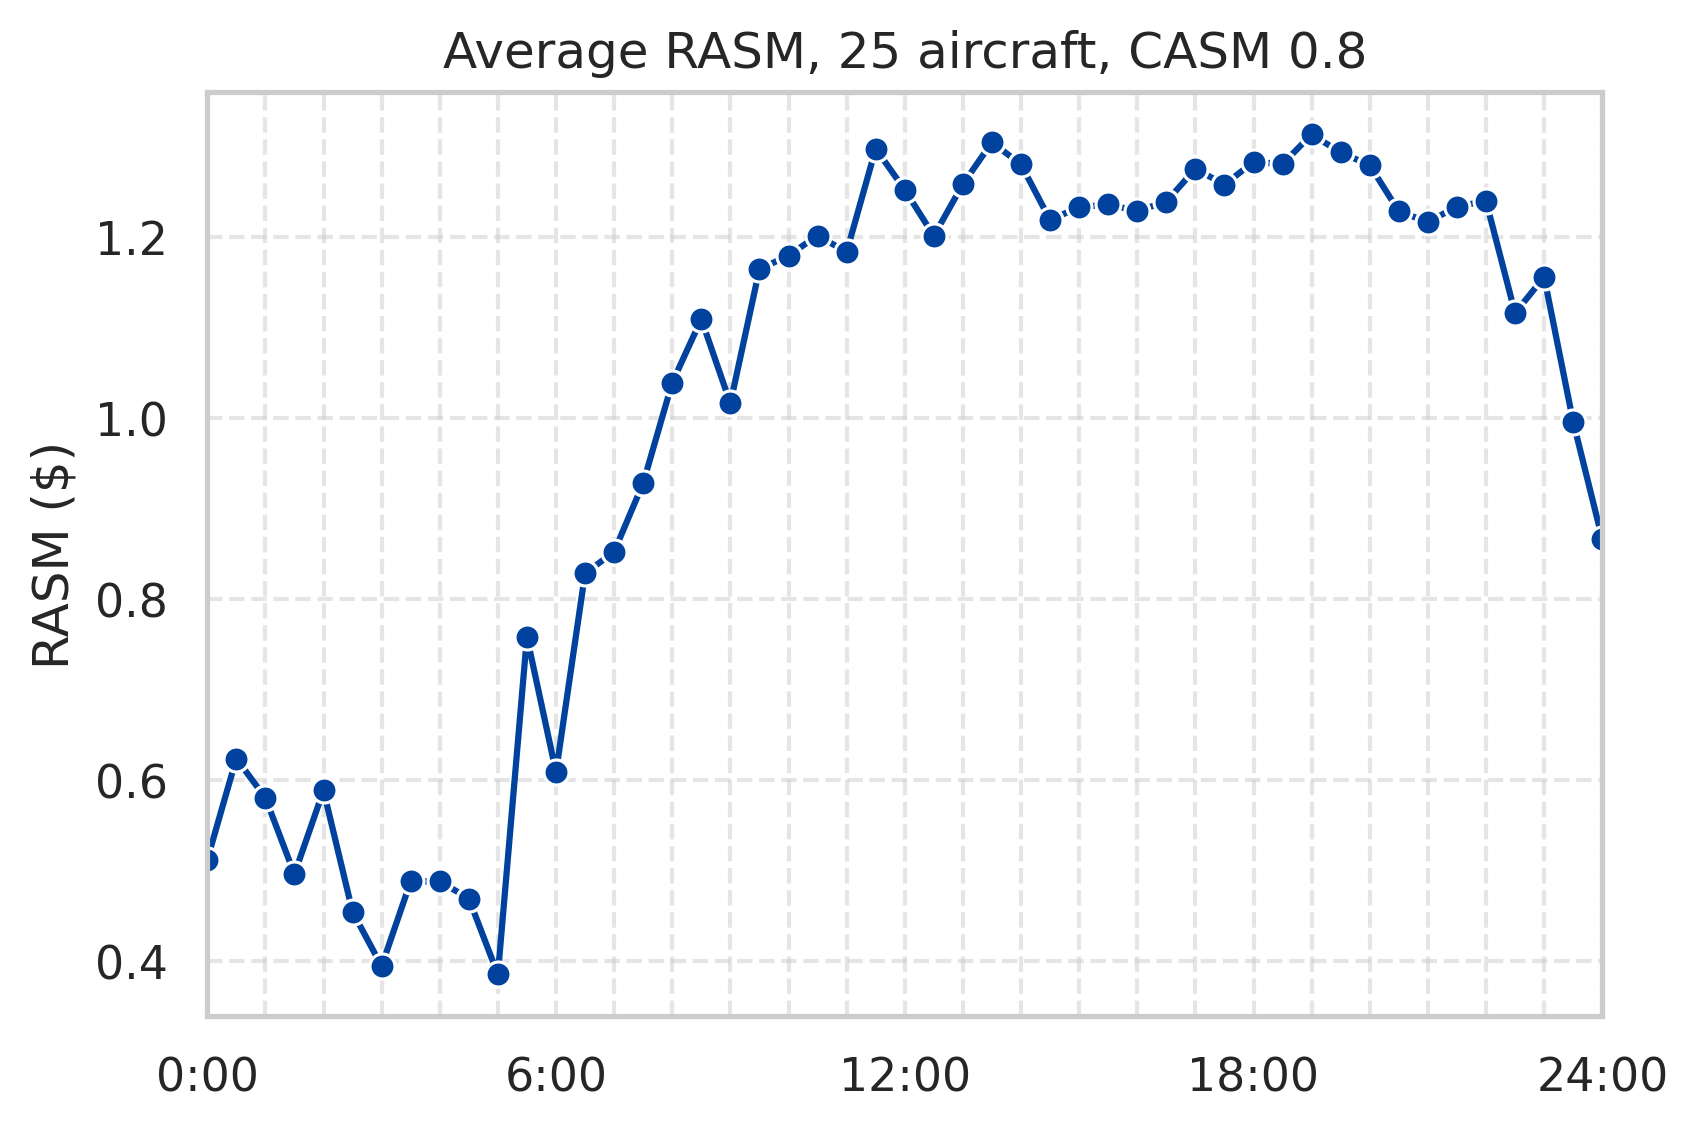

In [42]:
df = pd.read_csv("results/25_8.0.csv")
pricingSummary = PricingOpSummary(network, df)
fig, ax = pricingSummary.plot_average_rasm(dpi=300)
ax.set(title="Average RASM, 25 aircraft, CASM 0.8")

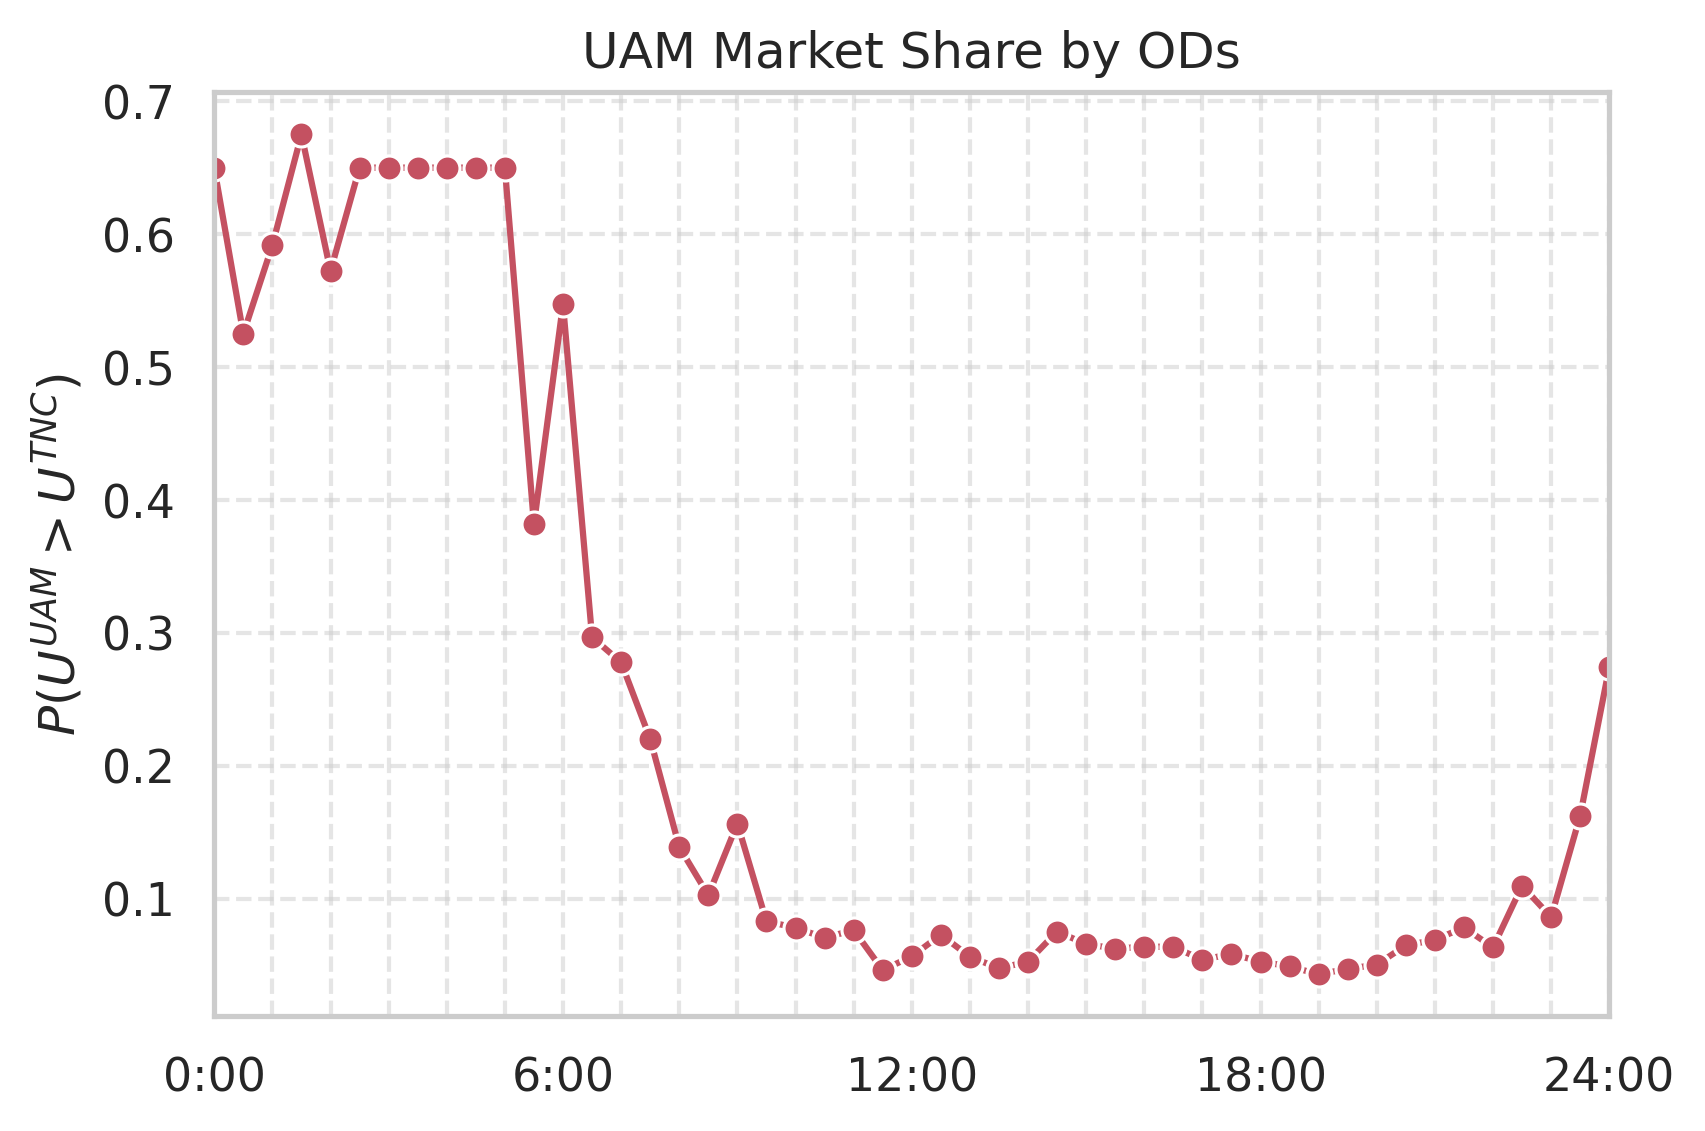

In [44]:
fig, ax = pricingSummary.plot_uam_share_by_od(dpi=300);
ax.get_legend().remove()